# LADA: Validacion de Estrategia de Transferencia de Algoritmos

## Objetivo
Validar experimentalmente si el algoritmo optimo de NIVEL_1 (basado en NUM_CURSOS)
es tambien optimo para NIVEL_2 y NIVEL_3 (combinaciones especificas).

## Hipotesis a Validar
**"El comportamiento de los algoritmos depende mas de la dimensionalidad del problema
(numero de cursos) que de la combinacion especifica de asignaturas."**

## Metodologia de Validacion
Comparamos 3 estrategias para cada combinacion de NIVEL_2:

1. **Oracle (Ideal)**: Random Search especifico para esa combinacion - limite inferior de error
2. **Estrategia NIVEL_1**: Usar algoritmo ganador segun NUM_CURSOS - nuestra propuesta
3. **Baseline Global**: Usar algoritmo ganador en todo el dataset - alternativa simple

## Criterio de Exito
- Si NIVEL_1 es significativamente mejor que Global -> hipotesis validada
- Si NIVEL_1 es similar a Global -> hipotesis rechazada (usar modelo global)

---

## NOTA: Secciones 1-4 copiadas del notebook principal

## 1. Importación de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans  # NUEVO para v4
from sklearn.mixture import GaussianMixture  # NUEVO para v4
import warnings
from typing import Dict, List, Tuple
from collections import defaultdict
import itertools
import skfuzzy as fuzz
import time  # NUEVO para v4 - medir tiempos de entrenamiento
import random  # NUEVO para v4 - Random Search

warnings.filterwarnings("ignore")
plt.style.use("default")
sns.set_palette("husl")
%matplotlib inline

## 2. Carga y Preparación de Datos

Cargamos los datasets necesarios según el análisis de "Punto 6 Completo.pdf":

In [2]:
# Rutas de datos
DATA_PATH = '../data/'


# Dataset 1: Historial de materias (CRÍTICO - contiene combinaciones de cursos)
df_materias = pd.read_parquet(f'{DATA_PATH}historial_materias_estudiante_anonymized.parquet')
print(f" Historial de materias: {df_materias.shape[0]:,} registros, {df_materias.shape[1]} columnas")

# Dataset 2: Rendimiento académico (CRÍTICO - contiene calificaciones)
df_rendimiento = pd.read_parquet(f'{DATA_PATH}historial_rendimiento_academico_estudiante_anonymized.parquet')
print(f" Rendimiento académico: {df_rendimiento.shape[0]:,} registros, {df_rendimiento.shape[1]} columnas")

# Dataset 3: Percentiles académicos (IMPORTANTE - normaliza rendimiento por programa)
df_percentiles = pd.read_parquet(f'{DATA_PATH}percentiles_academicos_estudiante_anonymized.parquet')
print(f" Percentiles académicos: {df_percentiles.shape[0]:,} registros, {df_percentiles.shape[1]} columnas")

# Dataset 4: Información actual (COMPLEMENTARIO - contexto del estudiante)
df_info_actual = pd.read_parquet(f'{DATA_PATH}informacion_actual_estudiante_anonymized.parquet')
print(f" Información actual: {df_info_actual.shape[0]:,} registros, {df_info_actual.shape[1]} columnas")

# Dataset 5: Riesgos históricos (IMPORTANTE - indicadores de alerta)
df_riesgos = pd.read_parquet(f'{DATA_PATH}riesgos_historicos_estudiante_pregrado_anonymized.parquet')
print(f" Riesgos históricos: {df_riesgos.shape[0]:,} registros, {df_riesgos.shape[1]} columnas")

df_facultades_departamentos = pd.read_parquet(f'{DATA_PATH}oferta_academica_anonymized.parquet')
print(f" Oferta Academica: {df_facultades_departamentos.shape[0]:,} registros, {df_facultades_departamentos.shape[1]} columnas")

 Historial de materias: 4,931,740 registros, 15 columnas
 Rendimiento académico: 611,654 registros, 22 columnas
 Percentiles académicos: 158,429 registros, 11 columnas
 Información actual: 222,407 registros, 30 columnas
 Riesgos históricos: 369,370 registros, 12 columnas
 Oferta Academica: 334,547 registros, 5 columnas


In [3]:
df_riesgos

,CODIGO_ESTUDIANTE,PERIODO,tres_o_mas_materias_parcialmente_perdidas,tres_o_mas_materias_retiradas,bajo_promedio_segundo_semestre,bajo_promedio_tercer_semestre_o_mas,bajo_promedio_movil,pocos_creditos_inscritos_para_matricula_pagada,materias_bloqueantes,semestres_perdidos_con_estado_normal,no_lectura_ingles_sexto_semestre,porcentaje_creditos_aprobados_menor_50
0,EST_00042995,201010,NaN,NaN,0,0,0,None,None,NaN,1,0
1,EST_00035971,201010,NaN,NaN,0,0,0,None,None,NaN,1,0
2,EST_00031069,201010,NaN,NaN,0,0,0,None,None,NaN,1,0
3,EST_00038662,201010,NaN,NaN,0,0,0,None,None,NaN,1,0
4,EST_00037862,201010,NaN,NaN,0,0,0,None,None,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
369365,EST_00096885,202520,NaN,NaN,0,0,0,None,None,NaN,0,1
369366,EST_00128383,202520,NaN,NaN,0,0,1,None,None,NaN,0,0
369367,EST_00055796,202520,NaN,NaN,0,1,0,None,None,NaN,0,0
369368,EST_00126999,202520,NaN,NaN,0,0,0,None,"[{'materia': 'MATE-1201', 'veces': 4}]",NaN,0,1


## 3. Preprocesamiento de Datos

### 3.1 Limpieza y Filtrado Inicial

In [4]:
print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# 1. HISTORIAL DE MATERIAS: Filtrar solo pregrado y materias históricas completas
print("\n1. Procesando historial de materias...")

df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].assign(
    EXITO=lambda x: (x['RESULTADO'] == 'APROBADO').astype('int8'),
    CODIGO_CURSO=lambda x: x['CODIGO_CURSO'].astype(str),
    PERIODO=lambda x: x['PERIODO'].astype(str)
)

# Deduplicar facultades por (CODIGO_CURSO, PERIODO)
df_facultades_clean = df_facultades_departamentos[
    ['CODIGO_CURSO', 'PERIODO', 'CODIGO_DEPARTAMENTO', 'CODIGO_FACULTAD']
].drop_duplicates(subset=['CODIGO_CURSO', 'PERIODO'], keep='first').astype({
    'CODIGO_CURSO': str,
    'PERIODO': str
})

# Merge por curso y período
df_materias_clean = df_materias_clean.merge(
    df_facultades_clean,
    on=['CODIGO_CURSO', 'PERIODO'],
    how='left',
    validate='m:1'
)

print(f"  Merge completado: {len(df_materias_clean)} registros")

PREPROCESAMIENTO DE DATOS

1. Procesando historial de materias...
  Merge completado: 3624475 registros


In [5]:
print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# 1. HISTORIAL DE MATERIAS: Filtrar solo pregrado y materias históricas completas
print("\n1. Procesando historial de materias...")

df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].assign(
    EXITO=lambda x: (x['RESULTADO'] == 'APROBADO').astype('int8'),
    CODIGO_CURSO=lambda x: x['CODIGO_CURSO'].astype(str),
    PERIODO=lambda x: x['PERIODO'].astype(str)
)

# Deduplicar facultades por (CODIGO_CURSO, PERIODO)
df_facultades_clean = df_facultades_departamentos[
    ['CODIGO_CURSO', 'PERIODO', 'CODIGO_DEPARTAMENTO', 'CODIGO_FACULTAD']
].drop_duplicates(subset=['CODIGO_CURSO', 'PERIODO'], keep='first').astype({
    'CODIGO_CURSO': str,
    'PERIODO': str
})

# Merge por curso y período
df_materias_clean = df_materias_clean.merge(
    df_facultades_clean,
    on=['CODIGO_CURSO', 'PERIODO'],
    how='left',
    validate='m:1'
)

print(f"   Merge completado: {len(df_materias_clean):,} registros")
print(f"   ✓ Registros originales: {len(df_materias):,}")
print(f"   ✓ Registros después de filtrado: {len(df_materias_clean):,}")
print(f"   ✓ Tasa de éxito general: {df_materias_clean['EXITO'].mean()*100:.2f}%")
print(f"   ✓ Cursos con departamento: {df_materias_clean['CODIGO_DEPARTAMENTO'].notna().sum():,} ({df_materias_clean['CODIGO_DEPARTAMENTO'].notna().mean()*100:.1f}%)")
print(f"   ✓ Cursos con facultad: {df_materias_clean['CODIGO_FACULTAD'].notna().sum():,} ({df_materias_clean['CODIGO_FACULTAD'].notna().mean()*100:.1f}%)")

# 2. RENDIMIENTO ACADÉMICO: Limpiar valores atípicos
print("\n2. Procesando rendimiento académico...")
df_rendimiento_clean = df_rendimiento[
    (df_rendimiento['PGA'].between(0, 5)) &
    (df_rendimiento['PORCENTAJE_CREDITOS_APROBADOS'].between(0, 100))
].copy()

print(f"   ✓ Registros originales: {len(df_rendimiento):,}")
print(f"   ✓ Registros después de limpieza: {len(df_rendimiento_clean):,}")
print(f"   ✓ PGA promedio: {df_rendimiento_clean['PGA'].mean():.2f}")
print(f"   ✓ % créditos aprobados promedio: {df_rendimiento_clean['PORCENTAJE_CREDITOS_APROBADOS'].mean():.2f}%")

# 3. PERCENTILES: Usar todos los datos disponibles
print("\n3. Procesando percentiles académicos...")
df_percentiles_clean = df_percentiles.copy()

print(f"   ✓ Registros totales: {len(df_percentiles_clean):,}")
if len(df_percentiles_clean) > 0 and 'PERCENTIL_PGA_PROGRAMA' in df_percentiles_clean.columns:
    print(f"   ✓ Percentil promedio: {df_percentiles_clean['PERCENTIL_PGA_PROGRAMA'].mean():.2f}")

# 4. RIESGOS: Convertir nulos en 0 (ausencia de riesgo)
print("\n4. Procesando indicadores de riesgo...")
df_riesgos_clean = df_riesgos.copy()

# Variables de riesgo binarias - solo usar las que existen
risk_binary_cols = [
    'bajo_promedio_segundo_semestre',
    'bajo_promedio_tercer_semestre_o_mas',
    'bajo_promedio_movil',
    'no_lectura_ingles_sexto_semestre',
    'porcentaje_creditos_aprobados_menor_50'
]

# Filtrar solo columnas que existen
risk_cols_disponibles = [col for col in risk_binary_cols if col in df_riesgos_clean.columns]

if risk_cols_disponibles:
    for col in risk_cols_disponibles:
        df_riesgos_clean[col] = df_riesgos_clean[col].fillna(0).astype(int)
    df_riesgos_clean['RIESGO_SCORE'] = df_riesgos_clean[risk_cols_disponibles].sum(axis=1)
else:
    df_riesgos_clean['RIESGO_SCORE'] = 0

print(f"   ✓ Columnas de riesgo encontradas: {len(risk_cols_disponibles)}/{len(risk_binary_cols)}")
if 'RIESGO_SCORE' in df_riesgos_clean.columns:
    print(f"   ✓ Score de riesgo promedio: {df_riesgos_clean['RIESGO_SCORE'].mean():.2f}")
    if df_riesgos_clean['RIESGO_SCORE'].max() > 0:
        print(f"   ✓ Estudiantes con riesgo alto (≥3): {(df_riesgos_clean['RIESGO_SCORE'] >= 3).sum():,} ({(df_riesgos_clean['RIESGO_SCORE'] >= 3).mean()*100:.2f}%)")

# 5. FACULTADES Y DEPARTAMENTOS
print("\n5. Procesando facultades y departamentos...")
print(f"   ✓ Cursos únicos: {df_facultades_departamentos['CODIGO_CURSO'].nunique():,}")
print(f"   ✓ Departamentos únicos: {df_facultades_departamentos['CODIGO_DEPARTAMENTO'].nunique():,}")
print(f"   ✓ Facultades únicas: {df_facultades_departamentos['CODIGO_FACULTAD'].nunique():,}")

print("\n" + "="*80)
print("✓ PREPROCESAMIENTO COMPLETADO")
print("="*80)

PREPROCESAMIENTO DE DATOS

1. Procesando historial de materias...
   Merge completado: 3,624,475 registros
   ✓ Registros originales: 4,931,740
   ✓ Registros después de filtrado: 3,624,475
   ✓ Tasa de éxito general: 93.77%
   ✓ Cursos con departamento: 3,624,358 (100.0%)
   ✓ Cursos con facultad: 3,624,358 (100.0%)

2. Procesando rendimiento académico...
   ✓ Registros originales: 611,654
   ✓ Registros después de limpieza: 611,654
   ✓ PGA promedio: 3.97
   ✓ % créditos aprobados promedio: 0.89%

3. Procesando percentiles académicos...
   ✓ Registros totales: 158,429
   ✓ Percentil promedio: 49.80

4. Procesando indicadores de riesgo...
   ✓ Columnas de riesgo encontradas: 5/5
   ✓ Score de riesgo promedio: 1.04
   ✓ Estudiantes con riesgo alto (≥3): 3,393 (0.92%)

5. Procesando facultades y departamentos...
   ✓ Cursos únicos: 26,544
   ✓ Departamentos únicos: 70
   ✓ Facultades únicas: 21

✓ PREPROCESAMIENTO COMPLETADO


### 3.2 Construcción de Dataset Integrado para Clustering

Integramos todos los datasets usando `CODIGO_ESTUDIANTE` como llave primaria:

In [6]:
print("CONSTRUCCIÓN DE DATASET INTEGRADO")


# Obtener el último registro por estudiante de cada dataset
print("Agregando datos por estudiante...")

# Rendimiento: último registro
df_rendimiento_ultimo = df_rendimiento_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Rendimiento: {len(df_rendimiento_ultimo):,} estudiantes")

# Percentiles: último registro
df_percentiles_ultimo = df_percentiles_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Percentiles: {len(df_percentiles_ultimo):,} estudiantes")

# Riesgos: último registro
df_riesgos_ultimo = df_riesgos_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Riesgos: {len(df_riesgos_ultimo):,} estudiantes")

# Info actual: último registro
df_info_ultimo = df_info_actual.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Información actual: {len(df_info_ultimo):,} estudiantes")

print("Integrando datasets...")

# Comenzar con rendimiento como base
df_estudiantes = df_rendimiento_ultimo[[
    'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA', 'PROMEDIO_SEMESTRAL',
    'CREDITOS_PGA', 'PORCENTAJE_CREDITOS_APROBADOS',
    'CREDITOS_REPROBADOS', 'CREDITOS_RETIRADOS',
    'TOTAL_SEMESTRES_MATRICULADOS'
]].copy()

# Agregar percentiles (si existen datos)
if len(df_percentiles_ultimo) > 0:
    # Verificar qué columnas existen realmente
    cols_percentiles = ['CODIGO_ESTUDIANTE']
    if 'PERCENTIL_PGA_PROGRAMA' in df_percentiles_ultimo.columns:
        cols_percentiles.append('PERCENTIL_PGA_PROGRAMA')
    if 'PROGRAMA' in df_percentiles_ultimo.columns:
        cols_percentiles.append('PROGRAMA')
    if 'GRUPO_SEMESTRES' in df_percentiles_ultimo.columns:
        cols_percentiles.append('GRUPO_SEMESTRES')
    
    df_estudiantes = df_estudiantes.merge(
        df_percentiles_ultimo[cols_percentiles],
        on='CODIGO_ESTUDIANTE',
        how='left'
    )
else:
    print(" No hay datos de percentiles para integrar")

# Agregar riesgos
df_estudiantes = df_estudiantes.merge(
    df_riesgos_ultimo[['CODIGO_ESTUDIANTE', 'RIESGO_SCORE']],
    on='CODIGO_ESTUDIANTE',
    how='left'
)

# Agregar información contextual
cols_info = ['CODIGO_ESTUDIANTE']
if 'CODIGO_PROGRAMA_1' in df_info_ultimo.columns:
    cols_info.append('CODIGO_PROGRAMA_1')
if 'ESTRATO_SOCIOECONOMICO' in df_info_ultimo.columns:
    cols_info.append('ESTRATO_SOCIOECONOMICO')

df_estudiantes = df_estudiantes.merge(
    df_info_ultimo[cols_info],
    on='CODIGO_ESTUDIANTE',
    how='left'
)

# Llenar nulos con valores seguros
if 'RIESGO_SCORE' in df_estudiantes.columns:
    df_estudiantes['RIESGO_SCORE'] = df_estudiantes['RIESGO_SCORE'].fillna(0)

if 'PERCENTIL_PGA_PROGRAMA' in df_estudiantes.columns:
    # Imputar percentil con mediana o con 50 si no hay datos
    median_percentil = df_estudiantes['PERCENTIL_PGA_PROGRAMA'].median()
    if pd.isna(median_percentil):
        median_percentil = 50  # Valor neutral
    df_estudiantes['PERCENTIL_PGA_PROGRAMA'] = df_estudiantes['PERCENTIL_PGA_PROGRAMA'].fillna(median_percentil)

# NO eliminar registros - trabajar con todos los estudiantes disponibles
print(f"\n Dataset integrado creado: {len(df_estudiantes):,} estudiantes")
print(f" Variables disponibles: {df_estudiantes.shape[1]}")

# Mostrar resumen estadístico
print("Resumen estadístico del dataset integrado:")
print(df_estudiantes.describe().round(2))

print("DATASET INTEGRADO COMPLETADO")

CONSTRUCCIÓN DE DATASET INTEGRADO
Agregando datos por estudiante...
 Rendimiento: 99,985 estudiantes
 Percentiles: 118,061 estudiantes
 Riesgos: 46,615 estudiantes
 Información actual: 222,407 estudiantes
Integrando datasets...

 Dataset integrado creado: 99,985 estudiantes
 Variables disponibles: 15
Resumen estadístico del dataset integrado:
         PERIODO       PGA  PROMEDIO_SEMESTRAL  CREDITOS_PGA  \
count   99985.00  99985.00            99983.00      99985.00   
mean   201938.97      3.87                3.24         72.33   
std       493.15      0.91                1.78         67.03   
min    201010.00      0.00                0.00          0.00   
25%    201515.00      3.72                2.48         20.00   
50%    202010.00      4.09                4.07         40.00   
75%    202420.00      4.36                4.50        133.00   
max    202520.00      5.00                5.00        389.00   

       PORCENTAJE_CREDITOS_APROBADOS  CREDITOS_REPROBADOS  CREDITOS_RETIRADOS 

In [7]:


# Comenzar con rendimiento como base
df_estudiantes = df_rendimiento_ultimo[[
    'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA', 'PROMEDIO_SEMESTRAL',
    'CREDITOS_PGA', 'PORCENTAJE_CREDITOS_APROBADOS',
    'CREDITOS_REPROBADOS', 'CREDITOS_RETIRADOS',
    'TOTAL_SEMESTRES_MATRICULADOS'
]].copy()


In [8]:
df_estudiantes

,CODIGO_ESTUDIANTE,PERIODO,PGA,PROMEDIO_SEMESTRAL,CREDITOS_PGA,PORCENTAJE_CREDITOS_APROBADOS,CREDITOS_REPROBADOS,CREDITOS_RETIRADOS,TOTAL_SEMESTRES_MATRICULADOS
0,EST_00000010,201513,4.29,3.00,44.0,1.000000,0.0,0.0,4.50
1,EST_00000012,202514,4.20,4.20,4.0,1.000000,0.0,0.0,NaN
2,EST_00000018,201010,4.42,4.50,28.0,1.000000,0.0,0.0,3.00
3,EST_00000021,201310,3.70,0.00,20.0,0.857143,6.0,0.0,4.50
4,EST_00000027,201110,3.68,1.50,11.0,0.727273,3.0,0.0,1.25
...,...,...,...,...,...,...,...,...,...
99980,EST_00141760,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN
99981,EST_00141771,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN
99982,EST_00141773,202514,5.00,5.00,4.0,1.000000,0.0,0.0,NaN
99983,EST_00141775,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN


In [9]:
df_estudiantes[df_estudiantes["PERIODO"]== 202418]

,CODIGO_ESTUDIANTE,PERIODO,PGA,PROMEDIO_SEMESTRAL,CREDITOS_PGA,PORCENTAJE_CREDITOS_APROBADOS,CREDITOS_REPROBADOS,CREDITOS_RETIRADOS,TOTAL_SEMESTRES_MATRICULADOS
14801,EST_00047281,202418,4.46,0.0,0.0,0.975309,0.0,4.0,12.25
51142,EST_00087341,202418,4.20,0.0,0.0,0.916667,0.0,4.0,4.00
64037,EST_00101096,202418,4.53,0.0,0.0,0.909091,0.0,4.0,2.00
66965,EST_00104173,202418,3.94,0.0,0.0,0.718085,3.0,50.0,10.00
71113,EST_00108635,202418,3.59,0.0,0.0,0.852071,3.0,22.0,8.00


In [10]:
import pandas as pd
import numpy as np

# Definir las nomenclaturas válidas
def clasificar_periodo(periodo):
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return 'especial'
    
    sufijo = int(periodo_str[-2:])
    
    if sufijo == 10:
        return 'semestre_1'
    elif sufijo == 20:
        return 'semestre_2'
    elif sufijo == 18:
        return 'verano'
    elif sufijo == 19:
        return 'intersemestral'
    elif sufijo in [11, 12, 13, 14, 15]:
        return 'ciclo_posgrado'
    else:
        return 'especial'

# Aplicar clasificación
periodos_unicos = sorted(df_estudiantes['PERIODO'].unique())
clasificacion = pd.Series(periodos_unicos).apply(clasificar_periodo)

# Contar por categoría
conteo = clasificacion.value_counts()
print("Conteo por tipo de período:")
print(conteo)

print("\n--- Períodos especiales ---")
especiales = [p for p in periodos_unicos if clasificar_periodo(p) == 'especial']
print(especiales)

# También contar registros (no solo períodos únicos)
df_estudiantes['tipo_periodo'] = df_estudiantes['PERIODO'].apply(clasificar_periodo)
print("\n--- Registros por tipo de período ---")
print(df_estudiantes['tipo_periodo'].value_counts())

Conteo por tipo de período:
ciclo_posgrado    76
semestre_1        16
semestre_2        16
especial           8
verano             6
intersemestral     6
Name: count, dtype: int64

--- Períodos especiales ---
[np.int64(202105), np.int64(202201), np.int64(202302), np.int64(202405), np.int64(202429), np.int64(202503), np.int64(202504), np.int64(202505)]

--- Registros por tipo de período ---
tipo_periodo
semestre_2        46216
semestre_1        43953
ciclo_posgrado     9580
intersemestral      158
verano               69
especial              9
Name: count, dtype: int64


In [11]:
df_materias

,PERIODO,CODIGO_ESTUDIANTE,NIVEL_ACADEMICO_ESTUDIANTE,CRN,CODIGO_CURSO,NUMERO_CREDITOS,SECCION,CODIGO_MODO_DE_CALIFICACION,CALIFICACION_PARCIAL,CALIFICACION_FINAL,ESTATUS,ATRIBUTOS,CODIGO_CAMPUS,RESULTADO,ES_HISTORICO_ACTUAL
0,202220,EST_00111501,Pregrado,CRN_00049774,CRS_00017889,3.0,1,N,None,RETIRADO,EN PROGRESO,VIRT-CURSO VIRTUAL,V,RETIRADO,SI
1,202220,EST_00111783,Pregrado,CRN_00054795,CRS_00002925,3.0,9,N,1.00,RETIRADO,EN PROGRESO,None,P,RETIRADO,SI
2,202220,EST_00111480,Pregrado,CRN_00068632,CRS_00017357,3.0,4,N,4.51,4.57,HISTORIA,None,P,APROBADO,SI
3,202220,EST_00113554,Pregrado,CRN_00004959,CRS_00005901,3.0,3,N,4.24,4.35,HISTORIA,INGL-CURSO DICTADO EN INGLES,P,APROBADO,SI
4,202220,EST_00112278,Magíster,CRN_00007396,CRS_00016778,6.0,1,N,--,4.80,HISTORIA,None,P,APROBADO,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931735,200010,EST_00002484,Pregrado,CRN_00064178,CRS_00004187,3.0,4,N,--,2.5,HISTORIA,None,P,REPROBADO,SI
4931736,200010,EST_00002290,Pregrado,CRN_00032441,CRS_00004743,3.0,2,N,--,4.0,HISTORIA,None,P,APROBADO,SI
4931737,200010,EST_00002297,Pregrado,CRN_00051760,CRS_00004906,3.0,1,N,--,3.0,HISTORIA,None,P,APROBADO,SI
4931738,200010,EST_00002234,Pregrado,CRN_00022897,CRS_00000543,3.0,1,N,--,4.5,HISTORIA,None,P,APROBADO,SI


## 4. Construcción de los 3 Niveles Jerárquicos

Implementamos los tres niveles de especificidad para el atributo de cursos:

- **Nivel 1**: Número total de cursos
- **Nivel 2**: Número de cursos por categoría temática
- **Nivel 3**: Códigos específicos de cursos

In [12]:
def extraer_categoria_curso(codigo_curso, df_facultades_departamentos, usar_departamento=False):
    """
    Extrae la categoría del curso usando facultades o departamentos.
    
    Parámetros:
    - codigo_curso: Código del curso (ej: CRS_00002925)
    - df_facultades_departamentos: DataFrame con CODIGO_CURSO, CODIGO_DEPARTAMENTO, CODIGO_FACULTAD
    - usar_departamento: Si True usa DEPARTAMENTO, si False usa FACULTAD
    """
    if pd.isna(codigo_curso):
        return 'DESCONOCIDO'
    
    match = df_facultades_departamentos[df_facultades_departamentos['CODIGO_CURSO'] == codigo_curso]
    
    if len(match) == 0:
        return 'DESCONOCIDO'
    
    if usar_departamento:
        codigo = match['CODIGO_DEPARTAMENTO'].iloc[0]
        return f"DEPT_{codigo}" if pd.notna(codigo) else 'DESCONOCIDO'
    else:
        codigo = match['CODIGO_FACULTAD'].iloc[0]
        return f"FAC_{codigo}" if pd.notna(codigo) else 'DESCONOCIDO'

In [13]:
print("CONSTRUCCIÓN DE NIVELES JERÁRQUICOS")
usar_departamento_nivel2 = True

print("Procesando inscripciones por semestre...")

# Agrupar materias por estudiante y periodo
df_inscripciones = df_materias_clean.groupby(['CODIGO_ESTUDIANTE', 'PERIODO'], as_index=False).agg({
    'CODIGO_CURSO': list,
    'NUMERO_CREDITOS': ['sum', 'count'],
    'EXITO': 'mean'  
})

# Aplanar nombres de columnas
df_inscripciones.columns = ['CODIGO_ESTUDIANTE', 'PERIODO', 'CURSOS_LISTA', 
                             'CREDITOS_TOTALES', 'NUM_CURSOS', 'TASA_EXITO']

print(f" Procesados {len(df_inscripciones):,} semestres de inscripciones")

# NIVEL 1: Número total de cursos
print("\nConstruyendo Nivel 1 (Número total de cursos)...")
df_inscripciones['NIVEL_1'] = df_inscripciones['NUM_CURSOS'].astype(str)
print(f"✓ Distribución Nivel 1:")
print(df_inscripciones['NIVEL_1'].value_counts().head(10))

# PREPARAR MAPEO: Crear diccionario curso -> categoría UNA SOLA VEZ
print(f"\nPreparando mapeo curso -> categoría...")
col_categoria = 'CODIGO_DEPARTAMENTO' if usar_departamento_nivel2 else 'CODIGO_FACULTAD'
prefijo = 'DEPT_' if usar_departamento_nivel2 else 'FAC_'

# Mapeo eficiente: curso -> categoría
mapeo_curso_cat = df_facultades_departamentos.drop_duplicates(subset=['CODIGO_CURSO']).set_index('CODIGO_CURSO')[col_categoria].to_dict()

# Rellenar con 'DESCONOCIDO' para cursos no encontrados
mapeo_curso_cat = {k: f"{prefijo}{v}" if pd.notna(v) else 'DESCONOCIDO' 
                   for k, v in mapeo_curso_cat.items()}

# NIVEL 2: Número de cursos por categoría
print(f"\nConstruyendo Nivel 2 (usando {'DEPARTAMENTO' if usar_departamento_nivel2 else 'FACULTAD'})...")

def construir_nivel_2(cursos_lista):
    """Cuenta cursos por categoría usando mapeo pre-calculado."""
    categorias = [mapeo_curso_cat.get(str(curso), 'DESCONOCIDO') for curso in cursos_lista]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    return firma

df_inscripciones['NIVEL_2'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_2)
print(f"✓ Categorías únicas en Nivel 2: {df_inscripciones['NIVEL_2'].nunique():,}")
print(f"✓ Top 5 combinaciones más comunes:")
print(df_inscripciones['NIVEL_2'].value_counts().head(5))

# NIVEL 3: Códigos específicos de cursos
print("\nConstruyendo Nivel 3 (Códigos específicos de cursos)...")

df_inscripciones['NIVEL_3'] = df_inscripciones['CURSOS_LISTA'].apply(
    lambda x: '_'.join(sorted([str(c) for c in x]))
)
print(f"✓ Combinaciones únicas en Nivel 3: {df_inscripciones['NIVEL_3'].nunique():,}")

print(f"\n✓ NIVELES CONSTRUIDOS - NIVEL_2 usa: {'DEPARTAMENTO' if usar_departamento_nivel2 else 'FACULTAD'}")

CONSTRUCCIÓN DE NIVELES JERÁRQUICOS
Procesando inscripciones por semestre...
 Procesados 698,436 semestres de inscripciones

Construyendo Nivel 1 (Número total de cursos)...
✓ Distribución Nivel 1:
NIVEL_1
6     178947
7     114850
5     110205
1      85506
8      54032
3      42511
4      42135
2      38131
9      20652
10      7648
Name: count, dtype: int64

Preparando mapeo curso -> categoría...

Construyendo Nivel 2 (usando DEPARTAMENTO)...
✓ Categorías únicas en Nivel 2: 234,407
✓ Top 5 combinaciones más comunes:
NIVEL_2
DEPT_MATE:1    15871
DEPT_IIND:1    10600
DEPT_ECON:1     5571
DEPT_ADMI:1     5285
DEPT_FISI:1     4900
Name: count, dtype: int64

Construyendo Nivel 3 (Códigos específicos de cursos)...
✓ Combinaciones únicas en Nivel 3: 534,811

✓ NIVELES CONSTRUIDOS - NIVEL_2 usa: DEPARTAMENTO


In [14]:
def clasificar_periodo(periodo):
    """
    Clasifica el tipo de periodo academico.
    
    Formato: YYYYPP donde YYYY=anio, PP=tipo
    - 10: Primer semestre
    - 20: Segundo semestre
    - 18: Verano
    - 19: Intersemestral
    - 11-15: Ciclos posgrado
    - Otros: especial (outliers)
    """
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return "especial"
    
    sufijo = int(periodo_str[-2:])
    
    if sufijo == 10:
        return "semestre_1"
    elif sufijo == 20:
        return "semestre_2"
    elif sufijo == 18:
        return "verano"
    elif sufijo == 19:
        return "intersemestral"
    elif sufijo in [11, 12, 13, 14, 15]:
        return "ciclo_posgrado"
    else:
        return "especial"


In [15]:
import pandas as pd
import numpy as np

def calcular_pga_anterior(df_inscripciones, df_rendimiento, df_info_actual):
    """
    Calcula PGA_ANTERIOR y caracteristicas adicionales del periodo anterior.

    NUEVO en v3: Agrega TOTAL_SEMESTRES_MATRICULADOS y PORCENTAJE_CREDITOS_APROBADOS
    para mejorar el clustering.
    """
    print("Iniciando calculo optimizado con caracteristicas adicionales (v3)...")

    # 1. PREPARACION DE DATOS
    df_ins = df_inscripciones[['CODIGO_ESTUDIANTE', 'PERIODO']].copy()

    # Historico de rendimiento - AHORA CON MAS CARACTERISTICAS
    df_hist = df_rendimiento[[
        'CODIGO_ESTUDIANTE',
        'PERIODO',
        'PGA',
        'TOTAL_SEMESTRES_MATRICULADOS',
        'PORCENTAJE_CREDITOS_APROBADOS'
    ]].copy()

    # Asegurarnos de que sean numericos
    df_hist['PGA'] = pd.to_numeric(df_hist['PGA'], errors='coerce')
    df_hist['TOTAL_SEMESTRES_MATRICULADOS'] = pd.to_numeric(df_hist['TOTAL_SEMESTRES_MATRICULADOS'], errors='coerce')
    df_hist['PORCENTAJE_CREDITOS_APROBADOS'] = pd.to_numeric(df_hist['PORCENTAJE_CREDITOS_APROBADOS'], errors='coerce')

    # CALCULAR PROMEDIO GENERAL DE % CREDITOS APROBADOS (para casos ICFES)
    pct_creditos_promedio = df_hist['PORCENTAJE_CREDITOS_APROBADOS'].mean()
    print(f"  Promedio general de % creditos aprobados: {pct_creditos_promedio:.2f}%")

    # Renombrar para el merge
    df_hist = df_hist.rename(columns={
        'PERIODO': 'PERIODO_HIST',
        'PGA': 'PGA_HIST',
        'TOTAL_SEMESTRES_MATRICULADOS': 'SEMESTRES_HIST',
        'PORCENTAJE_CREDITOS_APROBADOS': 'PCT_CREDITOS_HIST'
    })

    # ICFES para casos sin historial
    df_icfes = df_info_actual[['CODIGO_ESTUDIANTE', 'PUNTAJE_ICFES']].copy()
    df_icfes['PUNTAJE_ICFES'] = pd.to_numeric(df_icfes['PUNTAJE_ICFES'], errors='coerce')

    # 2. ORDENAMIENTO (Necesario para merge_asof)
    df_ins = df_ins.sort_values('PERIODO')
    df_hist = df_hist.sort_values('PERIODO_HIST')

    print("Realizando cruce historico (merge_asof)...")

    # 3. BUSCAR DATOS DEL PERIODO ANTERIOR
    # Busca en el pasado (direction='backward') pero NO incluye el periodo actual
    df_merged = pd.merge_asof(
        df_ins,
        df_hist,
        left_on='PERIODO',
        right_on='PERIODO_HIST',
        by='CODIGO_ESTUDIANTE',
        direction='backward',
        allow_exact_matches=False  # NO usa el mismo PERIODO
    )

    print("Realizando cruce con ICFES...")

    # 4. CRUZAR CON INFO DE ICFES
    df_final = pd.merge(df_merged, df_icfes, on='CODIGO_ESTUDIANTE', how='left')

    # 5. LOGICA DE SELECCION
    tiene_historia = df_final['PGA_HIST'].notna()
    tiene_icfes = df_final['PUNTAJE_ICFES'].notna()

    # Inicializar columnas finales
    df_final['PGA_ANTERIOR'] = np.nan
    df_final['SEMESTRES_ANTERIORES'] = np.nan
    df_final['PCT_CREDITOS_ANTERIOR'] = np.nan
    df_final['FUENTE_PGA'] = 'SIN_DATOS'

    # CASO 1: Tiene historial academico previo
    print(f"  Estudiantes con historial previo: {tiene_historia.sum():,}")
    df_final.loc[tiene_historia, 'PGA_ANTERIOR'] = df_final.loc[tiene_historia, 'PGA_HIST']
    df_final.loc[tiene_historia, 'SEMESTRES_ANTERIORES'] = df_final.loc[tiene_historia, 'SEMESTRES_HIST']
    df_final.loc[tiene_historia, 'PCT_CREDITOS_ANTERIOR'] = df_final.loc[tiene_historia, 'PCT_CREDITOS_HIST']
    df_final.loc[tiene_historia, 'PERIODO_FUENTE_PGA'] = df_final.loc[tiene_historia, 'PERIODO_HIST']
    df_final.loc[tiene_historia, 'FUENTE_PGA'] = 'PGA_HISTORICO'

    # CASO 2: No tiene historial, usa ICFES normalizado
    mask_icfes = (~tiene_historia) & (tiene_icfes)
    print(f"  Estudiantes sin historial, usando ICFES: {mask_icfes.sum():,}")

    puntaje_normalizado = (df_final.loc[mask_icfes, 'PUNTAJE_ICFES'] / 500.0) * 5.0
    df_final.loc[mask_icfes, 'PGA_ANTERIOR'] = puntaje_normalizado
    df_final.loc[mask_icfes, 'SEMESTRES_ANTERIORES'] = 0  # Primer semestre
    df_final.loc[mask_icfes, 'PCT_CREDITOS_ANTERIOR'] = pct_creditos_promedio  # Promedio general (no 100%)
    df_final.loc[mask_icfes, 'FUENTE_PGA'] = 'ICFES_NORMALIZADO'

    # CASO 3: Sin datos (ni historial ni ICFES)
    sin_datos = (~tiene_historia) & (~tiene_icfes)
    print(f"  Estudiantes SIN DATOS: {sin_datos.sum():,}")

    # 6. COLUMNAS FINALES
    columnas_retorno = [
        'CODIGO_ESTUDIANTE', 'PERIODO',
        'PGA_ANTERIOR',
        'SEMESTRES_ANTERIORES',
        'PCT_CREDITOS_ANTERIOR',
        'PERIODO_FUENTE_PGA',
        'FUENTE_PGA'
    ]

    resultado = df_final[columnas_retorno].copy()

    print("\nResumen de caracteristicas calculadas:")
    print(f"  PGA_ANTERIOR: min={resultado['PGA_ANTERIOR'].min():.2f}, max={resultado['PGA_ANTERIOR'].max():.2f}, mean={resultado['PGA_ANTERIOR'].mean():.2f}")
    print(f"  SEMESTRES_ANTERIORES: min={resultado['SEMESTRES_ANTERIORES'].min():.0f}, max={resultado['SEMESTRES_ANTERIORES'].max():.0f}, mean={resultado['SEMESTRES_ANTERIORES'].mean():.1f}")
    print(f"  PCT_CREDITOS_ANTERIOR: min={resultado['PCT_CREDITOS_ANTERIOR'].min():.1f}%, max={resultado['PCT_CREDITOS_ANTERIOR'].max():.1f}%, mean={resultado['PCT_CREDITOS_ANTERIOR'].mean():.1f}%")

    return resultado

print("Funcion calcular_pga_anterior (v3) definida - Casos ICFES usan promedio general de % creditos")


Funcion calcular_pga_anterior (v3) definida - Casos ICFES usan promedio general de % creditos


In [16]:
print("Filtrando periodos especiales...")
print(f"Inscripciones antes del filtro: {len(df_inscripciones):,}")
print(f"Rendimiento antes del filtro: {len(df_rendimiento_clean):,}")

# Clasificar periodos
df_inscripciones["TIPO_PERIODO"] = df_inscripciones["PERIODO"].apply(clasificar_periodo)
df_rendimiento_clean["TIPO_PERIODO"] = df_rendimiento_clean["PERIODO"].apply(clasificar_periodo)

# Mostrar distribucion
print("\nDistribucion de tipos de periodo en inscripciones:")
print(df_inscripciones["TIPO_PERIODO"].value_counts())

# Eliminar periodos especiales (outliers)
df_inscripciones = df_inscripciones[df_inscripciones["TIPO_PERIODO"] != "especial"].copy()
df_rendimiento_clean = df_rendimiento_clean[df_rendimiento_clean["TIPO_PERIODO"] != "especial"].copy()

print(f"\nInscripciones despues del filtro: {len(df_inscripciones):,}")
print(f"Rendimiento despues del filtro: {len(df_rendimiento_clean):,}")


Filtrando periodos especiales...
Inscripciones antes del filtro: 698,436
Rendimiento antes del filtro: 611,654

Distribucion de tipos de periodo en inscripciones:
TIPO_PERIODO
semestre_1        315820
semestre_2        312092
intersemestral     61276
verano              9206
especial              26
ciclo_posgrado        16
Name: count, dtype: int64

Inscripciones despues del filtro: 698,410
Rendimiento despues del filtro: 611,633


In [17]:
# Antes de llamar a calcular_pga_anterior, asegurar que PERIODO sea del mismo tipo

# Convertir PERIODO a int en todos los DataFrames
df_inscripciones['PERIODO'] = df_inscripciones['PERIODO'].astype(int)
df_rendimiento_clean['PERIODO'] = df_rendimiento_clean['PERIODO'].astype(int)
df_info_actual['PERIODO'] = df_info_actual['PERIODO'].astype(int)

# Ahora sí llamar a la función
df_pga_anterior = calcular_pga_anterior(df_inscripciones, df_rendimiento_clean, df_info_actual)

# Merge con inscripciones
df_inscripciones = df_inscripciones.merge(
    df_pga_anterior,
    on=["CODIGO_ESTUDIANTE", "PERIODO"],
    how="left"
)

print("\nDistribucion de fuentes de PGA:")
print(df_inscripciones["FUENTE_PGA"].value_counts())

# Filtrar solo registros con PGA valido
df_inscripciones_validas = df_inscripciones[df_inscripciones["PGA_ANTERIOR"].notna()].copy()

print(f"\nRegistros totales: {len(df_inscripciones):,}")
print(f"Registros con PGA valido: {len(df_inscripciones_validas):,}")
print(f"Registros descartados (sin PGA ni ICFES): {len(df_inscripciones) - len(df_inscripciones_validas):,}")

# Estadisticas de PGA_ANTERIOR
print(f"\nEstadisticas de PGA_ANTERIOR:")
print(df_inscripciones_validas["PGA_ANTERIOR"].describe())

# Usar df_inscripciones_validas de aqui en adelante
df_inscripciones = df_inscripciones_validas.copy()

Iniciando calculo optimizado con caracteristicas adicionales (v3)...
  Promedio general de % creditos aprobados: 0.89%
Realizando cruce historico (merge_asof)...
Realizando cruce con ICFES...
  Estudiantes con historial previo: 415,761
  Estudiantes sin historial, usando ICFES: 31,669
  Estudiantes SIN DATOS: 250,980

Resumen de caracteristicas calculadas:
  PGA_ANTERIOR: min=0.00, max=5.00, mean=3.88
  SEMESTRES_ANTERIORES: min=0, max=32, mean=5.1
  PCT_CREDITOS_ANTERIOR: min=0.0%, max=1.0%, mean=0.9%

Distribucion de fuentes de PGA:
FUENTE_PGA
PGA_HISTORICO        415761
SIN_DATOS            250980
ICFES_NORMALIZADO     31669
Name: count, dtype: int64

Registros totales: 698,410
Registros con PGA valido: 447,430
Registros descartados (sin PGA ni ICFES): 250,980

Estadisticas de PGA_ANTERIOR:
count    447430.000000
mean          3.880218
std           0.400826
min           0.000000
25%           3.620000
50%           3.890000
75%           4.160000
max           5.000000
Name: PGA_A

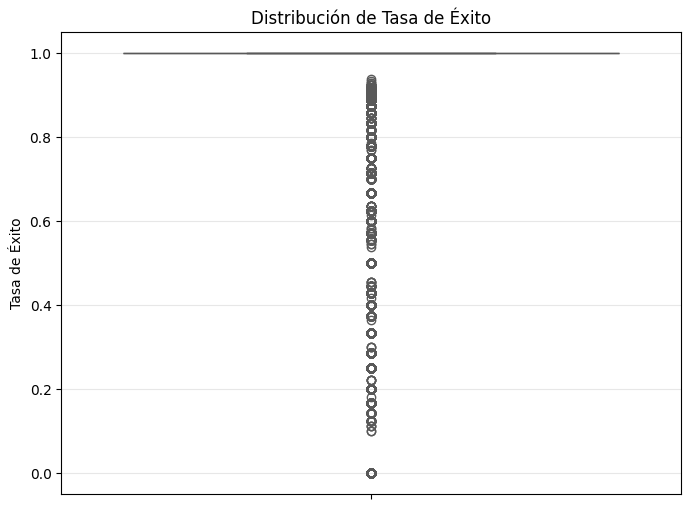

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_inscripciones, y="TASA_EXITO", palette="Set2")
plt.title('Distribución de Tasa de Éxito')
plt.ylabel('Tasa de Éxito')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [19]:
df_inscripciones["TASA_EXITO"].describe()

count    447430.000000
mean          0.934751
std           0.175213
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: TASA_EXITO, dtype: float64

In [20]:
print("Validando que no hay data leakage temporal...")

# Test 1: PGA_HISTORICO siempre debe venir de periodo anterior
historicos = df_inscripciones[df_inscripciones["FUENTE_PGA"] == "PGA_HISTORICO"]
violaciones = historicos[historicos["PERIODO_FUENTE_PGA"] >= historicos["PERIODO"]]

if len(violaciones) > 0:
    print(f"ERROR: {len(violaciones)} registros con PGA del futuro!")
    print(violaciones[["CODIGO_ESTUDIANTE", "PERIODO", "PERIODO_FUENTE_PGA"]].head())
else:
    print(f"Test 1 PASADO: Todos los PGA historicos ({len(historicos):,}) son de periodos anteriores")

# Test 2: ICFES debe estar en rango 0-5
icfes_norm = df_inscripciones[df_inscripciones["FUENTE_PGA"] == "ICFES_NORMALIZADO"]
if len(icfes_norm) > 0:
    min_icfes = icfes_norm["PGA_ANTERIOR"].min()
    max_icfes = icfes_norm["PGA_ANTERIOR"].max()
    print(f"Test 2 PASADO: ICFES normalizado en rango [{min_icfes:.2f}, {max_icfes:.2f}] (esperado: [0, 5])")
else:
    print("Test 2: No hay registros con ICFES normalizado")

# Test 3: Muestra aleatoria de verificacion
print("\nMuestra de 10 registros con PGA_ANTERIOR:")
muestra = df_inscripciones.sample(min(10, len(df_inscripciones)))
print(muestra[["CODIGO_ESTUDIANTE", "PERIODO", "PGA_ANTERIOR", "PERIODO_FUENTE_PGA", "FUENTE_PGA"]].to_string(index=False))


Validando que no hay data leakage temporal...
Test 1 PASADO: Todos los PGA historicos (415,761) son de periodos anteriores
Test 2 PASADO: ICFES normalizado en rango [1.63, 5.00] (esperado: [0, 5])

Muestra de 10 registros con PGA_ANTERIOR:
CODIGO_ESTUDIANTE  PERIODO  PGA_ANTERIOR  PERIODO_FUENTE_PGA    FUENTE_PGA
     EST_00073778   201720          3.90            201620.0 PGA_HISTORICO
     EST_00070636   201610          3.74            201520.0 PGA_HISTORICO
     EST_00066038   201610          3.48            201520.0 PGA_HISTORICO
     EST_00133385   202510          3.87            202420.0 PGA_HISTORICO
     EST_00070894   201520          3.91            201510.0 PGA_HISTORICO
     EST_00065912   201410          3.70            201320.0 PGA_HISTORICO
     EST_00062557   201220          4.09            201210.0 PGA_HISTORICO
     EST_00122008   202520          4.05            202510.0 PGA_HISTORICO
     EST_00096821   202020          3.81            202010.0 PGA_HISTORICO
     EST_0

In [21]:
print("SPLIT TEMPORAL DE DATOS (SIN DATA LEAKAGE)")


# Basado en análisis de LADA_analisis_temporal.ipynb
PERIODO_TRAIN_END = 202010
PERIODO_VAL_END = 202310

df_train = df_inscripciones[df_inscripciones['PERIODO'] <= PERIODO_TRAIN_END]#.sample(frac=0.10, random_state=42)
df_val = df_inscripciones[
    (df_inscripciones['PERIODO'] > PERIODO_TRAIN_END) &
    (df_inscripciones['PERIODO'] <= PERIODO_VAL_END)
].copy()
df_test = df_inscripciones[df_inscripciones['PERIODO'] > PERIODO_VAL_END].copy()

print(f"\nTRAIN SET:")
print(f"   Periodos: ≤ {PERIODO_TRAIN_END}")
print(f"   Registros: {len(df_train):,} ({len(df_train)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_train['CODIGO_ESTUDIANTE'].nunique():,}")
print(f"   Periodo mínimo: {df_train['PERIODO'].min()}")
print(f"   Periodo máximo: {df_train['PERIODO'].max()}")

print(f"\nVALIDATION SET:")
print(f"   Periodos: {PERIODO_TRAIN_END + 10} - {PERIODO_VAL_END}")
print(f"   Registros: {len(df_val):,} ({len(df_val)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_val['CODIGO_ESTUDIANTE'].nunique():,}")
if len(df_val) > 0:
    print(f"   Periodo mínimo: {df_val['PERIODO'].min()}")
    print(f"   Periodo máximo: {df_val['PERIODO'].max()}")

print(f"\nTEST SET:")
print(f"   Periodos: > {PERIODO_VAL_END}")
print(f"   Registros: {len(df_test):,} ({len(df_test)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_test['CODIGO_ESTUDIANTE'].nunique():,}")
if len(df_test) > 0:
    print(f"   Periodo mínimo: {df_test['PERIODO'].min()}")
    print(f"   Periodo máximo: {df_test['PERIODO'].max()}")

#assert len(df_train) + len(df_val) + len(df_test) == len(df_inscripciones), "Error: los splits no suman al total"

print("SPLIT TEMPORAL COMPLETADO - SIN DATA LEAKAGE")


SPLIT TEMPORAL DE DATOS (SIN DATA LEAKAGE)

TRAIN SET:
   Periodos: ≤ 202010
   Registros: 285,158 (63.7%)
   Estudiantes únicos: 40,747
   Periodo mínimo: 201015
   Periodo máximo: 202010

VALIDATION SET:
   Periodos: 202020 - 202310
   Registros: 90,019 (20.1%)
   Estudiantes únicos: 22,503
   Periodo mínimo: 202018
   Periodo máximo: 202310

TEST SET:
   Periodos: > 202310
   Registros: 72,253 (16.1%)
   Estudiantes únicos: 21,482
   Periodo mínimo: 202318
   Periodo máximo: 202520
SPLIT TEMPORAL COMPLETADO - SIN DATA LEAKAGE


---
## 5. Configuracion de Validacion de Algoritmos

A partir de aqui comienza la validacion experimental.

In [22]:
# ============================================================================
# PARAMETROS CONFIGURABLES PARA VALIDACION
# ============================================================================

# Porcentaje de muestra a utilizar (0.0 a 1.0)
PORCENTAJE_MUESTRA_NIVEL2 = 0.05  # 5% de NIVEL_2
PORCENTAJE_MUESTRA_NIVEL3 = 0.01  # 1% de NIVEL_3

# Nivel de confianza para calculo de margen de error
NIVEL_CONFIANZA = 0.95

# Numero de iteraciones de Random Search por algoritmo
N_ITER_RANDOM_SEARCH = 10

# Casos minimos requeridos para incluir una combinacion
MIN_CASOS_TRAIN = 10
MIN_CASOS_VAL = 5

# Semilla aleatoria para reproducibilidad
RANDOM_SEED = 42

print("Parametros configurados")
print(f"  - Muestra NIVEL_2: {PORCENTAJE_MUESTRA_NIVEL2*100:.1f}%")
print(f"  - Muestra NIVEL_3: {PORCENTAJE_MUESTRA_NIVEL3*100:.1f}%")
print(f"  - Iteraciones Random Search: {N_ITER_RANDOM_SEARCH}")
print(f"  - Nivel de confianza: {NIVEL_CONFIANZA*100:.0f}%")

Parametros configurados
  - Muestra NIVEL_2: 5.0%
  - Muestra NIVEL_3: 1.0%
  - Iteraciones Random Search: 10
  - Nivel de confianza: 95%


In [23]:
from scipy import stats

def calcular_tamano_muestra_optimo(N, confianza=0.95, margen_error=0.05, p=0.5):
    """Calcula el tamano de muestra optimo usando formula de poblacion finita."""
    z = stats.norm.ppf((1 + confianza) / 2)
    n_infinita = (z**2 * p * (1-p)) / (margen_error**2)
    n = n_infinita / (1 + (n_infinita - 1) / N)
    return int(np.ceil(n))

def calcular_margen_error(N, n, confianza=0.95, p=0.5):
    """Calcula el margen de error dado un tamano de muestra."""
    z = stats.norm.ppf((1 + confianza) / 2)
    fpc = np.sqrt((N - n) / (N - 1)) if N > n else 1.0
    margen = z * np.sqrt(p * (1-p) / n) * fpc
    return margen

def estimar_tiempo_ejecucion(n_combinaciones, n_iter=10, tiempo_por_iter=3):
    """Estima el tiempo total de ejecucion."""
    tiempo_total_seg = n_combinaciones * 3 * n_iter * tiempo_por_iter
    return {
        'segundos': tiempo_total_seg,
        'minutos': tiempo_total_seg / 60,
        'horas': tiempo_total_seg / 3600
    }

print("Funciones estadisticas definidas")

Funciones estadisticas definidas


In [24]:
# ============================================================================
# DEFINIR ALGORITMOS GANADORES DE NIVEL_1 (del notebook principal)
# ============================================================================
# TODO: Actualizar con los resultados reales del notebook principal

mejor_algoritmo_nivel1 = {
    '1': 'kmeans', '2': 'kmeans', '3': 'kmeans',
    '4': 'kmeans', '5': 'kmeans', '6': 'gmm',
    '7': 'gmm', '8': 'fuzzy', '9': 'fuzzy',
    '10': 'fuzzy', '11': 'gmm', '12': 'gmm',
    '13': 'kmeans', '14': 'kmeans', '15': 'kmeans',
}

print("Algoritmos ganadores por NUM_CURSOS (PLACEHOLDER - actualizar con resultados reales):")
for num_cursos, algo in sorted(mejor_algoritmo_nivel1.items(), key=lambda x: int(x[0])):
    print(f"  {num_cursos:>3} cursos -> {algo.upper()}")

Algoritmos ganadores por NUM_CURSOS (PLACEHOLDER - actualizar con resultados reales):
    1 cursos -> KMEANS
    2 cursos -> KMEANS
    3 cursos -> KMEANS
    4 cursos -> KMEANS
    5 cursos -> KMEANS
    6 cursos -> GMM
    7 cursos -> GMM
    8 cursos -> FUZZY
    9 cursos -> FUZZY
   10 cursos -> FUZZY
   11 cursos -> GMM
   12 cursos -> GMM
   13 cursos -> KMEANS
   14 cursos -> KMEANS
   15 cursos -> KMEANS


---
## 6. Analisis de Poblacion y Calculo de Muestra

In [25]:
# Obtener todas las combinaciones unicas
combinaciones_nivel2 = df_train['NIVEL_2'].unique()
combinaciones_nivel3 = df_train['NIVEL_3'].unique()

N_nivel2 = len(combinaciones_nivel2)
N_nivel3 = len(combinaciones_nivel3)

print("="*70)
print("ANALISIS DE POBLACION")
print("="*70)
print(f"Total combinaciones NIVEL_2: {N_nivel2:,}")
print(f"Total combinaciones NIVEL_3: {N_nivel3:,}")

# Calcular tamano de muestra optimo (margen de error +/-5%)
n_optimo_nivel2 = calcular_tamano_muestra_optimo(N_nivel2, NIVEL_CONFIANZA, margen_error=0.05)
n_optimo_nivel3 = calcular_tamano_muestra_optimo(N_nivel3, NIVEL_CONFIANZA, margen_error=0.05)

print(f"\nTamano de muestra OPTIMO (margen +/-5%, confianza 95%):")
print(f"  NIVEL_2: {n_optimo_nivel2:,} combinaciones ({n_optimo_nivel2/N_nivel2*100:.2f}%)")
print(f"  NIVEL_3: {n_optimo_nivel3:,} combinaciones ({n_optimo_nivel3/N_nivel3*100:.2f}%)")

# Calcular tamano segun porcentaje configurado
n_config_nivel2 = max(30, int(N_nivel2 * PORCENTAJE_MUESTRA_NIVEL2))
n_config_nivel3 = max(30, int(N_nivel3 * PORCENTAJE_MUESTRA_NIVEL3))

print(f"\nTamano de muestra CONFIGURADO:")
print(f"  NIVEL_2: {n_config_nivel2:,} combinaciones")
print(f"  NIVEL_3: {n_config_nivel3:,} combinaciones")

# Calcular margen de error
margen_nivel2 = calcular_margen_error(N_nivel2, n_config_nivel2, NIVEL_CONFIANZA)
margen_nivel3 = calcular_margen_error(N_nivel3, n_config_nivel3, NIVEL_CONFIANZA)

print(f"\nMargen de error con tamano configurado:")
print(f"  NIVEL_2: +/-{margen_nivel2*100:.2f}%")
print(f"  NIVEL_3: +/-{margen_nivel3*100:.2f}%")

# Estimacion de tiempo
tiempo_nivel2 = estimar_tiempo_ejecucion(n_config_nivel2, N_ITER_RANDOM_SEARCH)

print(f"\nTiempo estimado NIVEL_2: ~{tiempo_nivel2['minutos']:.0f} min")

ANALISIS DE POBLACION
Total combinaciones NIVEL_2: 111,074
Total combinaciones NIVEL_3: 220,886

Tamano de muestra OPTIMO (margen +/-5%, confianza 95%):
  NIVEL_2: 383 combinaciones (0.34%)
  NIVEL_3: 384 combinaciones (0.17%)

Tamano de muestra CONFIGURADO:
  NIVEL_2: 5,553 combinaciones
  NIVEL_3: 2,208 combinaciones

Margen de error con tamano configurado:
  NIVEL_2: +/-1.28%
  NIVEL_3: +/-2.08%

Tiempo estimado NIVEL_2: ~8330 min


---
## 7. Funciones de Clustering

In [26]:
# ============================================================================
# FUNCIONES DE CLUSTERING (OPTIMIZADAS)
# ============================================================================
from scipy.spatial.distance import cdist

def preparar_features_clustering(df_data, nivel='NIVEL_1'):
    """Prepara features para clustering"""
    required_cols = ['PGA_ANTERIOR', 'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR']

    df_valid = df_data[
        df_data['PGA_ANTERIOR'].notna() &
        df_data['SEMESTRES_ANTERIORES'].notna() &
        df_data['PCT_CREDITOS_ANTERIOR'].notna()
    ].copy()

    X = df_valid[[
        'PGA_ANTERIOR', 'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
        'NUM_CURSOS', 'CREDITOS_TOTALES'
    ]].copy()

    df_valid['NIVEL_ID'] = df_valid[nivel]

    return X.values, df_valid


def evaluar_modelo_vectorizado(centroides, tasas_exito, X_val_scaled, df_val):
    """
    Evaluacion VECTORIZADA - mucho mas rapida que bucles Python.

    Calcula MAE usando operaciones NumPy/SciPy optimizadas.
    Speedup esperado: 10-50x vs bucle Python.
    """
    # Calcular TODAS las distancias de una vez con cdist (optimizado en C)
    distancias = cdist(X_val_scaled, centroides, metric='euclidean')

    # Asignar cluster mas cercano (vectorizado)
    clusters = np.argmin(distancias, axis=1)

    # Mapear clusters a predicciones (vectorizado)
    n_clusters = centroides.shape[0]
    tasas_array = np.array([tasas_exito.get(c, 0.0) for c in range(n_clusters)])
    predicciones = tasas_array[clusters]

    # Obtener valores reales
    reales = df_val['TASA_EXITO'].values

    return mean_absolute_error(reales, predicciones)


def fuzzy_cmeans_clustering(X_scaled, X_original, df_data, params):
    """Aplica Fuzzy C-means clustering."""
    inicio = time.time()

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_scaled.T, c=params["n_clusters"], m=params["m"],
        error=params["error"], maxiter=params["maxiter"]
    )

    cluster_labels = np.argmax(u, axis=0)
    df_temp = df_data.copy()
    df_temp["CLUSTER"] = cluster_labels

    tasas_exito = df_temp.groupby("CLUSTER")["TASA_EXITO"].mean().to_dict()

    silhouette = silhouette_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0
    davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0

    return {
        "algoritmo": "fuzzy", "hiperparametros": params,
        "n_clusters": params["n_clusters"], "centroides": cntr.T,
        "cluster_labels": cluster_labels, "tasas_exito": tasas_exito,
        "silhouette": silhouette, "davies_bouldin": davies_bouldin,
        "tiempo_entrenamiento": time.time() - inicio, "total_casos": len(X_scaled)
    }


def kmeans_clustering(X_scaled, X_original, df_data, params):
    """Aplica K-means clustering."""
    inicio = time.time()

    kmeans = KMeans(
        n_clusters=params["n_clusters"], init=params["init"],
        n_init=params["n_init"], max_iter=params["max_iter"], random_state=RANDOM_SEED
    )
    cluster_labels = kmeans.fit_predict(X_scaled)

    df_temp = df_data.copy()
    df_temp["CLUSTER"] = cluster_labels
    tasas_exito = df_temp.groupby("CLUSTER")["TASA_EXITO"].mean().to_dict()

    silhouette = silhouette_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0
    davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0

    return {
        "algoritmo": "kmeans", "hiperparametros": params,
        "n_clusters": params["n_clusters"], "centroides": kmeans.cluster_centers_,
        "cluster_labels": cluster_labels, "tasas_exito": tasas_exito,
        "silhouette": silhouette, "davies_bouldin": davies_bouldin,
        "tiempo_entrenamiento": time.time() - inicio, "total_casos": len(X_scaled)
    }


def gmm_clustering(X_scaled, X_original, df_data, params):
    """Aplica Gaussian Mixture Models clustering."""
    inicio = time.time()

    gmm = GaussianMixture(
        n_components=params["n_components"], covariance_type=params["covariance_type"],
        max_iter=params["max_iter"], n_init=params["n_init"], random_state=RANDOM_SEED
    )
    gmm.fit(X_scaled)
    cluster_labels = gmm.predict(X_scaled)

    df_temp = df_data.copy()
    df_temp["CLUSTER"] = cluster_labels
    tasas_exito = df_temp.groupby("CLUSTER")["TASA_EXITO"].mean().to_dict()

    silhouette = silhouette_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0
    davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0.0

    return {
        "algoritmo": "gmm", "hiperparametros": params,
        "n_clusters": params["n_components"], "centroides": gmm.means_,
        "cluster_labels": cluster_labels, "tasas_exito": tasas_exito,
        "silhouette": silhouette, "davies_bouldin": davies_bouldin,
        "tiempo_entrenamiento": time.time() - inicio, "total_casos": len(X_scaled)
    }

print("Funciones de clustering definidas (OPTIMIZADAS con cdist)")

Funciones de clustering definidas (OPTIMIZADAS con cdist)


In [27]:
# Espacios de hiperparametros
param_spaces = {
    "fuzzy": {
        "n_clusters": [2, 3, 4, 5],
        "m": [1.5, 2.0, 2.5, 3.0],
        "error": [0.001, 0.005, 0.01],
        "maxiter": [1000]
    },
    "kmeans": {
        "n_clusters": [2, 3, 4, 5],
        "init": ["k-means++", "random"],
        "n_init": [10, 20],
        "max_iter": [300, 500]
    },
    "gmm": {
        "n_components": [2, 3, 4, 5],
        "covariance_type": ["full", "tied", "diag"],
        "max_iter": [100, 200],
        "n_init": [1, 3]
    }
}

def sample_random_params(param_space, seed=None):
    """Muestrea un conjunto aleatorio de hiperparametros."""
    if seed is not None:
        random.seed(seed)
    return {key: random.choice(values) for key, values in param_space.items()}

print("Espacios de hiperparametros definidos")

Espacios de hiperparametros definidos


---
## 8. Nota sobre Baseline Global

**El Baseline Global se calculará automáticamente** después del Random Search,
usando el algoritmo que gane más veces en la muestra.

Esto es más eficiente y estadísticamente válido que entrenar en todo el dataset.

In [30]:
# Baseline Global se calcula en la sección de comparación
# (usando el algoritmo más frecuente en la muestra)
print("Baseline Global: se calculará después del Random Search")

Baseline Global: se calculará después del Random Search


---
## 9. Muestreo Estratificado Optimizado

In [31]:
def muestreo_estratificado_proporcional(df_train, df_val, nivel_col, n_total,
                                          min_casos_train=10, min_casos_val=5):
    """
    Muestreo estratificado proporcional por NUM_CURSOS.

    OPTIMIZADO:
    - Filtra combinaciones con suficientes casos en train Y val
    - Mantiene proporcionalidad por NUM_CURSOS
    - Prioriza combinaciones con mas casos (mas representativas)
    """
    random.seed(RANDOM_SEED)

    # Contar casos por combinacion en train y val
    casos_train = df_train.groupby(nivel_col).size().to_dict()
    casos_val = df_val.groupby(nivel_col).size().to_dict()

    # Filtrar combinaciones validas (suficientes casos en ambos)
    combinaciones_validas = []
    for comb in df_train[nivel_col].unique():
        n_train = casos_train.get(comb, 0)
        n_val = casos_val.get(comb, 0)

        if n_train >= min_casos_train and n_val >= min_casos_val:
            # Obtener NUM_CURSOS de esta combinacion
            num_cursos = df_train[df_train[nivel_col] == comb]['NUM_CURSOS'].iloc[0]
            combinaciones_validas.append({
                'combinacion': comb,
                'num_cursos': num_cursos,
                'n_casos_train': n_train,
                'n_casos_val': n_val,
                'score': n_train + n_val  # Priorizar combinaciones con mas datos
            })

    if len(combinaciones_validas) == 0:
        print("ADVERTENCIA: No hay combinaciones validas")
        return pd.DataFrame()

    df_validas = pd.DataFrame(combinaciones_validas)
    print(f"Combinaciones validas (train>={min_casos_train}, val>={min_casos_val}): {len(df_validas):,}")

    # Distribucion por NUM_CURSOS
    distribucion = df_validas['num_cursos'].value_counts(normalize=True).sort_index()

    # Muestreo estratificado proporcional
    muestras = []
    for num_cursos, proporcion in distribucion.items():
        n_muestra = max(2, int(n_total * proporcion))

        # Combinaciones de este estrato, ordenadas por score (mas casos primero)
        estrato = df_validas[df_validas['num_cursos'] == num_cursos].sort_values('score', ascending=False)

        # Tomar muestra (priorizar las que tienen mas casos)
        n_muestra = min(n_muestra, len(estrato))
        muestra = estrato.head(n_muestra)
        muestras.append(muestra)

    resultado = pd.concat(muestras, ignore_index=True)

    print(f"Muestra final: {len(resultado):,} combinaciones")
    print(f"\nDistribucion por NUM_CURSOS:")
    print(resultado.groupby('num_cursos').size())

    return resultado

# Generar muestras
print("Generando muestras estratificadas...")
print()

muestra_nivel2 = muestreo_estratificado_proporcional(
    df_train, df_val, 'NIVEL_2', n_config_nivel2, MIN_CASOS_TRAIN, MIN_CASOS_VAL
)

print()
print(f"Muestra NIVEL_2: {len(muestra_nivel2):,} combinaciones seleccionadas")

Generando muestras estratificadas...

Combinaciones validas (train>=10, val>=5): 938
Muestra final: 938 combinaciones

Distribucion por NUM_CURSOS:
num_cursos
1      41
2     111
3     126
4      94
5     161
6     240
7     124
8      29
9       7
10      4
11      1
dtype: int64

Muestra NIVEL_2: 938 combinaciones seleccionadas


---
## 10. Random Search en Muestra de NIVEL_2

**ADVERTENCIA:** Esta celda puede tardar dependiendo del tamano de muestra.

In [32]:
# Preparar features para NIVEL_2
print("Preparando features para NIVEL_2...")
X_train_n2, df_train_n2 = preparar_features_clustering(df_train, nivel='NIVEL_2')
X_val_n2, df_val_n2 = preparar_features_clustering(df_val, nivel='NIVEL_2')

# Normalizar
scaler_n2 = StandardScaler()
X_train_n2_scaled = scaler_n2.fit_transform(X_train_n2)
X_val_n2_scaled = scaler_n2.transform(X_val_n2)

print(f"Features preparados: {len(X_train_n2):,} casos train, {len(X_val_n2):,} casos val")

Preparando features para NIVEL_2...
Features preparados: 285,157 casos train, 90,019 casos val


In [33]:
def random_search_combinacion(comb, df_train_feat, X_train_sc, X_train_orig,
                               df_val_feat, X_val_sc, nivel_col, n_iter=10):
    """
    Ejecuta Random Search para una combinacion especifica.
    OPTIMIZADO: Usa evaluacion vectorizada.
    """
    mask_train = (df_train_feat['NIVEL_ID'] == comb)
    mask_val = (df_val_feat['NIVEL_ID'] == comb)

    X_comb_train = X_train_sc[mask_train]
    X_comb_val = X_val_sc[mask_val]
    X_comb_train_orig = X_train_orig[mask_train]
    df_comb_train = df_train_feat[mask_train].copy()
    df_comb_val = df_val_feat[mask_val].copy()

    if len(X_comb_train) < MIN_CASOS_TRAIN or len(X_comb_val) < MIN_CASOS_VAL:
        return None

    resultados = []

    for algo_name in ['fuzzy', 'kmeans', 'gmm']:
        mejor_mae = float('inf')
        mejor_params = None
        mejor_resultado = None

        # Ajustar n_clusters segun datos disponibles
        param_space_ajustado = param_spaces[algo_name].copy()
        n_clusters_max = min(5, max(2, len(X_comb_train) // 10))

        if 'n_clusters' in param_space_ajustado:
            param_space_ajustado['n_clusters'] = [
                n for n in param_space_ajustado['n_clusters'] if n <= n_clusters_max
            ]
            if not param_space_ajustado['n_clusters']:
                param_space_ajustado['n_clusters'] = [2]

        if 'n_components' in param_space_ajustado:
            param_space_ajustado['n_components'] = [
                n for n in param_space_ajustado['n_components'] if n <= n_clusters_max
            ]
            if not param_space_ajustado['n_components']:
                param_space_ajustado['n_components'] = [2]

        for iter_num in range(n_iter):
            params = sample_random_params(param_space_ajustado, seed=RANDOM_SEED + iter_num)

            try:
                if algo_name == 'fuzzy':
                    resultado_train = fuzzy_cmeans_clustering(
                        X_comb_train, X_comb_train_orig, df_comb_train, params)
                elif algo_name == 'kmeans':
                    resultado_train = kmeans_clustering(
                        X_comb_train, X_comb_train_orig, df_comb_train, params)
                else:
                    resultado_train = gmm_clustering(
                        X_comb_train, X_comb_train_orig, df_comb_train, params)

                # EVALUACION VECTORIZADA (optimizada)
                mae = evaluar_modelo_vectorizado(
                    resultado_train['centroides'],
                    resultado_train['tasas_exito'],
                    X_comb_val,
                    df_comb_val
                )

                if mae < mejor_mae:
                    mejor_mae = mae
                    mejor_params = params
                    mejor_resultado = resultado_train

            except Exception:
                continue

        if mejor_resultado is not None:
            resultados.append({
                'algoritmo': algo_name,
                'mae_val': mejor_mae,
                'hiperparametros': mejor_params,
                'silhouette': mejor_resultado['silhouette'],
                'n_clusters': mejor_resultado['n_clusters']
            })

    return resultados if len(resultados) > 0 else None

print("Funcion de Random Search definida (OPTIMIZADA)")

Funcion de Random Search definida (OPTIMIZADA)


In [34]:
# Ejecutar Random Search en muestra de NIVEL_2
print("="*70)
print("EJECUTANDO RANDOM SEARCH EN MUESTRA DE NIVEL_2")
print("="*70)
print(f"Combinaciones a procesar: {len(muestra_nivel2):,}")
print()

resultados_validacion_nivel2 = []
tiempo_inicio = time.time()

for idx, row in muestra_nivel2.iterrows():
    comb = row['combinacion']
    num_cursos = row['num_cursos']

    # Progreso cada 10%
    progreso = ((idx + 1) / len(muestra_nivel2)) * 100
    if (idx + 1) % max(1, len(muestra_nivel2) // 10) == 5:
        tiempo_transcurrido = (time.time() - tiempo_inicio) / 60
        print(f"[{progreso:.0f}%] {idx+1}/{len(muestra_nivel2)} | Tiempo: {tiempo_transcurrido:.1f} min")

    resultados_comb = random_search_combinacion(
        comb, df_train_n2, X_train_n2_scaled, X_train_n2,
        df_val_n2, X_val_n2_scaled, 'NIVEL_2', N_ITER_RANDOM_SEARCH
    )

    if resultados_comb is not None:
        for res in resultados_comb:
            resultados_validacion_nivel2.append({
                'combinacion': comb,
                'num_cursos': num_cursos,
                **res
            })

tiempo_total = (time.time() - tiempo_inicio) / 60
df_validacion_nivel2 = pd.DataFrame(resultados_validacion_nivel2)

print()
print(f"COMPLETADO - {len(df_validacion_nivel2):,} resultados en {tiempo_total:.1f} min")

EJECUTANDO RANDOM SEARCH EN MUESTRA DE NIVEL_2
Combinaciones a procesar: 938

[10%] 93/938 | Tiempo: 2.5 min
[20%] 186/938 | Tiempo: 3.9 min
[30%] 279/938 | Tiempo: 5.1 min
[40%] 372/938 | Tiempo: 6.3 min
[50%] 465/938 | Tiempo: 7.6 min
[59%] 558/938 | Tiempo: 8.9 min
[69%] 651/938 | Tiempo: 10.2 min
[79%] 744/938 | Tiempo: 11.2 min
[89%] 837/938 | Tiempo: 12.4 min
[99%] 930/938 | Tiempo: 13.5 min

COMPLETADO - 2,184 resultados en 13.6 min


In [ ]:
## Esto es de las partes mas demoradas de todo el ciclo se calcula que se puede demorar unos 20 minutos en hacer estos calculo

---
## 11. Comparacion de las 3 Estrategias

Para cada combinacion comparamos:
1. **Oracle**: Mejor algoritmo encontrado por Random Search (limite inferior)
2. **NIVEL_1**: Algoritmo segun NUM_CURSOS (nuestra propuesta)
3. **Global**: Algoritmo ganador en todo el dataset (baseline simple)

In [35]:
# ============================================================================
# COMPARACION DE LAS 3 ESTRATEGIAS
# ============================================================================

# Para cada combinación, obtener el mejor algoritmo (Oracle)
df_ganador_nivel2 = df_validacion_nivel2.loc[
    df_validacion_nivel2.groupby('combinacion')['mae_val'].idxmin()
].copy()

df_ganador_nivel2['algoritmo_oracle'] = df_ganador_nivel2['algoritmo']
df_ganador_nivel2['mae_oracle'] = df_ganador_nivel2['mae_val']

# ============================================================================
# CALCULAR BASELINE GLOBAL (desde los resultados del muestreo)
# ============================================================================
# El Baseline Global es el algoritmo que GANA MÁS VECES en la muestra
victorias = df_ganador_nivel2['algoritmo_oracle'].value_counts()
ALGORITMO_GLOBAL = victorias.idxmax()

print("="*70)
print("BASELINE GLOBAL (calculado desde la muestra)")
print("="*70)
print(f"Algoritmo más frecuente: {ALGORITMO_GLOBAL.upper()}")
print(f"Victorias: {victorias[ALGORITMO_GLOBAL]}/{len(df_ganador_nivel2)} ({victorias[ALGORITMO_GLOBAL]/len(df_ganador_nivel2)*100:.1f}%)")
print()
print("Distribución de victorias:")
for algo, count in victorias.items():
    marca = " <-- BASELINE" if algo == ALGORITMO_GLOBAL else ""
    print(f"  {algo.upper():8}: {count:3} victorias ({count/len(df_ganador_nivel2)*100:.1f}%){marca}")
print()

# ============================================================================
# ASIGNAR ESTRATEGIAS A CADA COMBINACIÓN
# ============================================================================

# Estrategia NIVEL_1: según mejor_algoritmo_nivel1[num_cursos]
df_ganador_nivel2['algoritmo_nivel1'] = df_ganador_nivel2['num_cursos'].astype(str).map(mejor_algoritmo_nivel1)

# Estrategia Global: siempre el mismo algoritmo
df_ganador_nivel2['algoritmo_global'] = ALGORITMO_GLOBAL

# ============================================================================
# OBTENER MAE DE CADA ESTRATEGIA
# ============================================================================

maes_nivel1 = []
maes_global = []

for idx, row in df_ganador_nivel2.iterrows():
    comb = row['combinacion']

    # MAE de estrategia NIVEL_1
    algo_n1 = row['algoritmo_nivel1']
    mae_n1 = df_validacion_nivel2[
        (df_validacion_nivel2['combinacion'] == comb) &
        (df_validacion_nivel2['algoritmo'] == algo_n1)
    ]['mae_val'].values
    maes_nivel1.append(mae_n1[0] if len(mae_n1) > 0 else np.nan)

    # MAE de estrategia Global
    mae_g = df_validacion_nivel2[
        (df_validacion_nivel2['combinacion'] == comb) &
        (df_validacion_nivel2['algoritmo'] == ALGORITMO_GLOBAL)
    ]['mae_val'].values
    maes_global.append(mae_g[0] if len(mae_g) > 0 else np.nan)

df_ganador_nivel2['mae_nivel1'] = maes_nivel1
df_ganador_nivel2['mae_global'] = maes_global

# Calcular coincidencias
df_ganador_nivel2['nivel1_es_oracle'] = (df_ganador_nivel2['algoritmo_nivel1'] == df_ganador_nivel2['algoritmo_oracle'])
df_ganador_nivel2['global_es_oracle'] = (df_ganador_nivel2['algoritmo_global'] == df_ganador_nivel2['algoritmo_oracle'])

# Calcular penalizaciones
df_ganador_nivel2['penalizacion_nivel1'] = df_ganador_nivel2['mae_nivel1'] - df_ganador_nivel2['mae_oracle']
df_ganador_nivel2['penalizacion_global'] = df_ganador_nivel2['mae_global'] - df_ganador_nivel2['mae_oracle']

# ============================================================================
# MOSTRAR RESULTADOS
# ============================================================================

print("="*70)
print("COMPARACION DE LAS 3 ESTRATEGIAS")
print("="*70)
print()
print(f"Combinaciones evaluadas: {len(df_ganador_nivel2):,}")
print(f"Margen de error estadistico: +/-{margen_nivel2*100:.2f}%")
print()
print("TASAS DE ACIERTO (coincide con Oracle):")
print(f"  NIVEL_1: {df_ganador_nivel2['nivel1_es_oracle'].mean()*100:.1f}%")
print(f"  Global:  {df_ganador_nivel2['global_es_oracle'].mean()*100:.1f}%")
print()
print("MAE PROMEDIO:")
print(f"  Oracle:  {df_ganador_nivel2['mae_oracle'].mean():.4f} (limite inferior)")
print(f"  NIVEL_1: {df_ganador_nivel2['mae_nivel1'].mean():.4f}")
print(f"  Global:  {df_ganador_nivel2['mae_global'].mean():.4f}")
print()
print("PENALIZACION PROMEDIO (vs Oracle):")
print(f"  NIVEL_1: +{df_ganador_nivel2['penalizacion_nivel1'].mean():.4f}")
print(f"  Global:  +{df_ganador_nivel2['penalizacion_global'].mean():.4f}")

BASELINE GLOBAL (calculado desde la muestra)
Algoritmo más frecuente: GMM
Victorias: 459/938 (48.9%)

Distribución de victorias:
  GMM     : 459 victorias (48.9%) <-- BASELINE
  KMEANS  : 358 victorias (38.2%)
  FUZZY   : 121 victorias (12.9%)

COMPARACION DE LAS 3 ESTRATEGIAS

Combinaciones evaluadas: 938
Margen de error estadistico: +/-1.28%

TASAS DE ACIERTO (coincide con Oracle):
  NIVEL_1: 39.6%
  Global:  48.9%

MAE PROMEDIO:
  Oracle:  0.0695 (limite inferior)
  NIVEL_1: 0.0810
  Global:  0.0730

PENALIZACION PROMEDIO (vs Oracle):
  NIVEL_1: +0.0099
  Global:  +0.0035


In [36]:
# ============================================================================
# TEST ESTADISTICO: NIVEL_1 vs GLOBAL
# ============================================================================
from scipy.stats import wilcoxon, ttest_rel

print("="*70)
print("TEST ESTADISTICO: NIVEL_1 vs GLOBAL")
print("="*70)
print()

# Filtrar casos validos (sin NaN)
df_test = df_ganador_nivel2.dropna(subset=['mae_nivel1', 'mae_global'])

if len(df_test) > 10:
    # Test de Wilcoxon (no parametrico, pareado)
    stat_w, p_value_w = wilcoxon(df_test['mae_nivel1'], df_test['mae_global'])

    # T-test pareado
    stat_t, p_value_t = ttest_rel(df_test['mae_nivel1'], df_test['mae_global'])

    print(f"n = {len(df_test)} combinaciones")
    print()
    print("Test de Wilcoxon (pareado, no parametrico):")
    print(f"  Estadistico: {stat_w:.2f}")
    print(f"  p-value: {p_value_w:.6f}")
    print(f"  Significativo (p<0.05): {'SI' if p_value_w < 0.05 else 'NO'}")
    print()
    print("T-test pareado:")
    print(f"  Estadistico: {stat_t:.2f}")
    print(f"  p-value: {p_value_t:.6f}")
    print(f"  Significativo (p<0.05): {'SI' if p_value_t < 0.05 else 'NO'}")
    print()

    # Interpretacion
    diff_mae = df_test['mae_nivel1'].mean() - df_test['mae_global'].mean()
    print("="*70)
    print("INTERPRETACION:")
    print("="*70)
    if p_value_w < 0.05:
        if diff_mae < 0:
            print("NIVEL_1 es SIGNIFICATIVAMENTE MEJOR que Global")
            print("-> La hipotesis de transferencia de meta-conocimiento es VALIDA")
        else:
            print("Global es SIGNIFICATIVAMENTE MEJOR que NIVEL_1")
            print("-> La hipotesis de transferencia de meta-conocimiento es RECHAZADA")
    else:
        print("NO hay diferencia significativa entre NIVEL_1 y Global")
        print("-> Ambas estrategias son equivalentes")
        print("   (Usar NIVEL_1 por ser mas interpretable)")
else:
    print("No hay suficientes datos para test estadistico")

TEST ESTADISTICO: NIVEL_1 vs GLOBAL

n = 907 combinaciones

Test de Wilcoxon (pareado, no parametrico):
  Estadistico: 16925.00
  p-value: 0.000000
  Significativo (p<0.05): SI

T-test pareado:
  Estadistico: 9.84
  p-value: 0.000000
  Significativo (p<0.05): SI

INTERPRETACION:
Global es SIGNIFICATIVAMENTE MEJOR que NIVEL_1
-> La hipotesis de transferencia de meta-conocimiento es RECHAZADA


---
## 12. Visualizaciones para el Paper

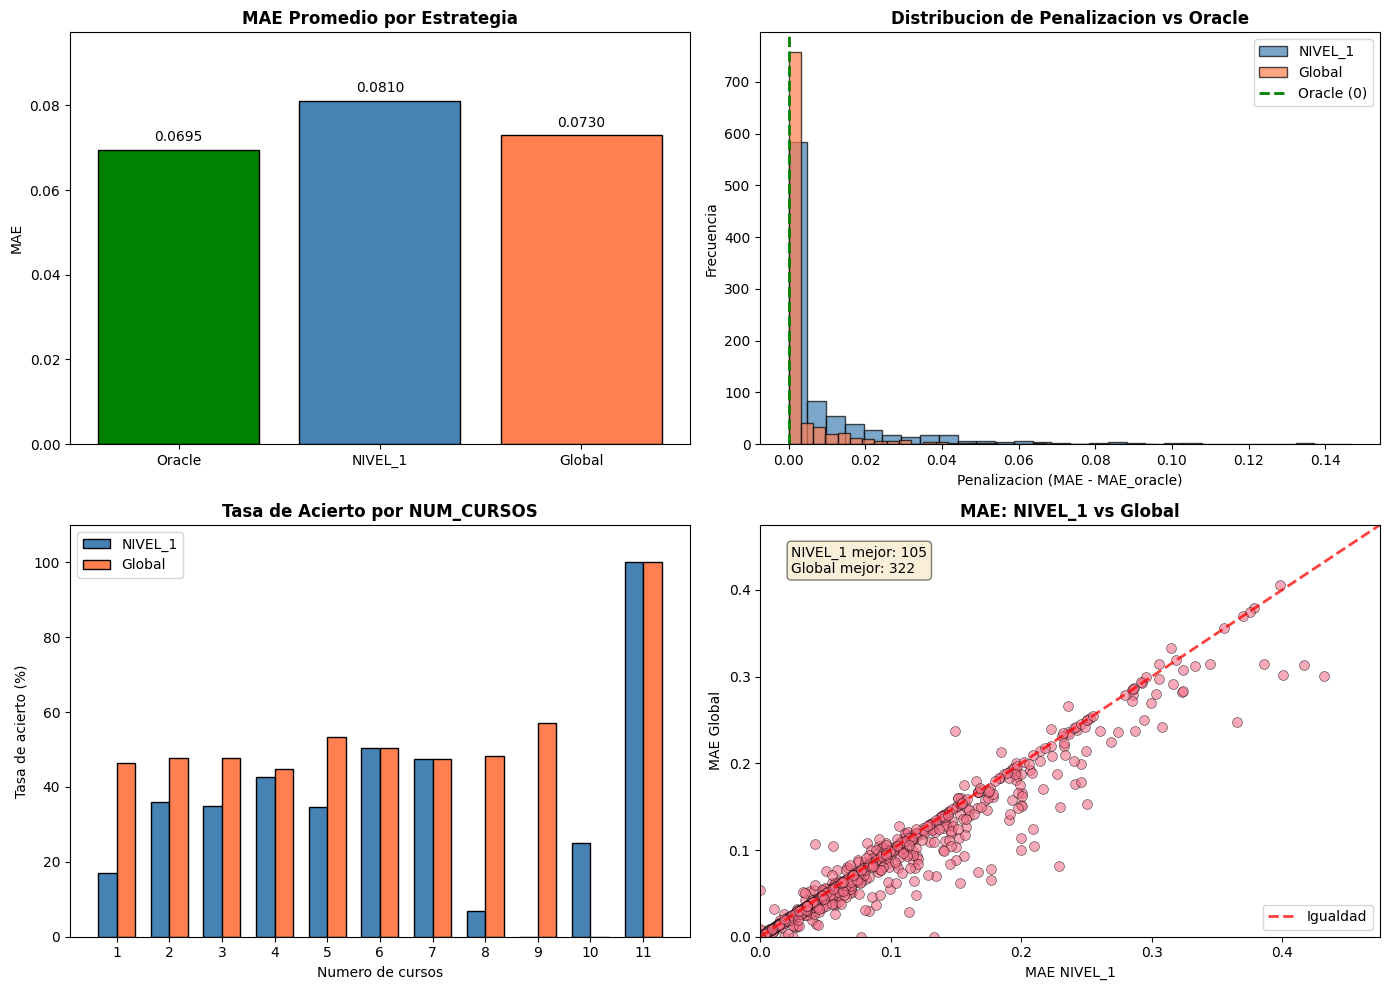

Visualizacion guardada en 'validacion_3_estrategias.png'


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparacion de MAE entre estrategias
ax1 = axes[0, 0]
estrategias = ['Oracle', 'NIVEL_1', 'Global']
maes = [
    df_ganador_nivel2['mae_oracle'].mean(),
    df_ganador_nivel2['mae_nivel1'].mean(),
    df_ganador_nivel2['mae_global'].mean()
]
colores = ['green', 'steelblue', 'coral']
bars = ax1.bar(estrategias, maes, color=colores, edgecolor='black')
ax1.set_title('MAE Promedio por Estrategia', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAE')
ax1.set_ylim(0, max(maes) * 1.2)
for bar, mae in zip(bars, maes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{mae:.4f}', ha='center', fontsize=10)

# 2. Distribucion de penalizacion
ax2 = axes[0, 1]
ax2.hist(df_ganador_nivel2['penalizacion_nivel1'].dropna(), bins=30, alpha=0.7,
         label='NIVEL_1', color='steelblue', edgecolor='black')
ax2.hist(df_ganador_nivel2['penalizacion_global'].dropna(), bins=30, alpha=0.7,
         label='Global', color='coral', edgecolor='black')
ax2.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Oracle (0)')
ax2.set_title('Distribucion de Penalizacion vs Oracle', fontsize=12, fontweight='bold')
ax2.set_xlabel('Penalizacion (MAE - MAE_oracle)')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# 3. Tasa de acierto por NUM_CURSOS
ax3 = axes[1, 0]
acierto_nivel1 = df_ganador_nivel2.groupby('num_cursos')['nivel1_es_oracle'].mean() * 100
acierto_global = df_ganador_nivel2.groupby('num_cursos')['global_es_oracle'].mean() * 100
x = np.arange(len(acierto_nivel1))
width = 0.35
ax3.bar(x - width/2, acierto_nivel1.values, width, label='NIVEL_1', color='steelblue', edgecolor='black')
ax3.bar(x + width/2, acierto_global.values, width, label='Global', color='coral', edgecolor='black')
ax3.set_xticks(x)
ax3.set_xticklabels(acierto_nivel1.index)
ax3.set_title('Tasa de Acierto por NUM_CURSOS', fontsize=12, fontweight='bold')
ax3.set_xlabel('Numero de cursos')
ax3.set_ylabel('Tasa de acierto (%)')
ax3.legend()
ax3.set_ylim(0, 110)

# 4. Scatter: MAE NIVEL_1 vs MAE Global
ax4 = axes[1, 1]
ax4.scatter(df_ganador_nivel2['mae_nivel1'], df_ganador_nivel2['mae_global'],
            alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
lims = [0, max(df_ganador_nivel2['mae_nivel1'].max(), df_ganador_nivel2['mae_global'].max()) * 1.1]
ax4.plot(lims, lims, 'r--', alpha=0.75, linewidth=2, label='Igualdad')
ax4.set_title('MAE: NIVEL_1 vs Global', fontsize=12, fontweight='bold')
ax4.set_xlabel('MAE NIVEL_1')
ax4.set_ylabel('MAE Global')
ax4.legend()
ax4.set_xlim(lims)
ax4.set_ylim(lims)

# Contar puntos
n_nivel1_mejor = (df_ganador_nivel2['mae_nivel1'] < df_ganador_nivel2['mae_global']).sum()
n_global_mejor = (df_ganador_nivel2['mae_global'] < df_ganador_nivel2['mae_nivel1']).sum()
ax4.text(0.05, 0.95, f'NIVEL_1 mejor: {n_nivel1_mejor}\nGlobal mejor: {n_global_mejor}',
         transform=ax4.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('validacion_3_estrategias.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizacion guardada en 'validacion_3_estrategias.png'")

---
## 13. Resumen Ejecutivo para el Paper

In [38]:
print("="*70)
print("RESUMEN EJECUTIVO PARA EL PAPER")
print("="*70)
print()

# Calcular metricas finales
tasa_acierto_n1 = df_ganador_nivel2['nivel1_es_oracle'].mean() * 100
tasa_acierto_g = df_ganador_nivel2['global_es_oracle'].mean() * 100
mae_oracle = df_ganador_nivel2['mae_oracle'].mean()
mae_n1 = df_ganador_nivel2['mae_nivel1'].mean()
mae_g = df_ganador_nivel2['mae_global'].mean()
pen_n1 = df_ganador_nivel2['penalizacion_nivel1'].mean()
pen_g = df_ganador_nivel2['penalizacion_global'].mean()

print(f"Hipotesis: 'El comportamiento de los algoritmos depende mas de la")
print(f"dimensionalidad (NUM_CURSOS) que de la combinacion especifica'")
print()
print(f"Metodologia:")
print(f"  - Muestra: {len(df_ganador_nivel2):,} combinaciones de NIVEL_2")
print(f"  - Margen de error: +/-{margen_nivel2*100:.2f}% (confianza 95%)")
print(f"  - Random Search: {N_ITER_RANDOM_SEARCH} iteraciones x 3 algoritmos")
print(f"  - Baseline Global: {ALGORITMO_GLOBAL.upper()} (mas frecuente en muestra)")
print()
print(f"Resultados:")
print(f"  {'Estrategia':<15} {'MAE':<10} {'Acierto':<10} {'Penalizacion':<12}")
print(f"  {'-'*47}")
print(f"  {'Oracle':<15} {mae_oracle:<10.4f} {'100.0%':<10} {'0.0000':<12}")
print(f"  {'NIVEL_1':<15} {mae_n1:<10.4f} {f'{tasa_acierto_n1:.1f}%':<10} {f'+{pen_n1:.4f}':<12}")
print(f"  {'Global':<15} {mae_g:<10.4f} {f'{tasa_acierto_g:.1f}%':<10} {f'+{pen_g:.4f}':<12}")
print()

# Conclusion
if pen_n1 < pen_g:
    mejora_pct = ((pen_g - pen_n1) / pen_g) * 100 if pen_g > 0 else 0
    print(f"Conclusion: NIVEL_1 reduce la penalizacion en {mejora_pct:.1f}% vs Global")
    print(f"La hipotesis de transferencia de meta-conocimiento es SOPORTADA.")
elif pen_n1 > pen_g:
    print(f"Conclusion: Global tiene menor penalizacion que NIVEL_1")
    print(f"La hipotesis de transferencia de meta-conocimiento es RECHAZADA.")
else:
    print(f"Conclusion: No hay diferencia significativa entre NIVEL_1 y Global")
    print(f"Ambas estrategias son equivalentes.")

RESUMEN EJECUTIVO PARA EL PAPER

Hipotesis: 'El comportamiento de los algoritmos depende mas de la
dimensionalidad (NUM_CURSOS) que de la combinacion especifica'

Metodologia:
  - Muestra: 938 combinaciones de NIVEL_2
  - Margen de error: +/-1.28% (confianza 95%)
  - Random Search: 10 iteraciones x 3 algoritmos
  - Baseline Global: GMM (mas frecuente en muestra)

Resultados:
  Estrategia      MAE        Acierto    Penalizacion
  -----------------------------------------------
  Oracle          0.0695     100.0%     0.0000      
  NIVEL_1         0.0810     39.6%      +0.0099     
  Global          0.0730     48.9%      +0.0035     

Conclusion: Global tiene menor penalizacion que NIVEL_1
La hipotesis de transferencia de meta-conocimiento es RECHAZADA.


In [39]:
# Guardar resultados
df_validacion_nivel2.to_csv('resultados_validacion_nivel2.csv', index=False)
df_ganador_nivel2.to_csv('comparacion_3_estrategias.csv', index=False)

print("Resultados guardados:")
print("  - resultados_validacion_nivel2.csv")
print("  - comparacion_3_estrategias.csv")
print("  - validacion_3_estrategias.png")

Resultados guardados:
  - resultados_validacion_nivel2.csv
  - comparacion_3_estrategias.csv
  - validacion_3_estrategias.png


In [40]:
print("="*70)
print("TABLA LaTeX PARA EL PAPER")
print("="*70)
print()
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Comparacion de estrategias de seleccion de algoritmo}")
print(r"\label{tab:validacion}")
print(r"\begin{tabular}{lccc}")
print(r"\hline")
print(r"\textbf{Estrategia} & \textbf{MAE} & \textbf{Acierto} & \textbf{Penalizacion} \\")
print(r"\hline")
print(f"Oracle (ideal) & {mae_oracle:.4f} & 100.0\% & 0.0000 \\")
print(f"NIVEL\_1 (propuesta) & {mae_n1:.4f} & {tasa_acierto_n1:.1f}\% & +{pen_n1:.4f} \\")
print(f"Global (baseline) & {mae_g:.4f} & {tasa_acierto_g:.1f}\% & +{pen_g:.4f} \\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

TABLA LaTeX PARA EL PAPER

\begin{table}[h]
\centering
\caption{Comparacion de estrategias de seleccion de algoritmo}
\label{tab:validacion}
\begin{tabular}{lccc}
\hline
\textbf{Estrategia} & \textbf{MAE} & \textbf{Acierto} & \textbf{Penalizacion} \\
\hline
Oracle (ideal) & 0.0695 & 100.0\% & 0.0000 \
NIVEL\_1 (propuesta) & 0.0810 & 39.6\% & +0.0099 \
Global (baseline) & 0.0730 & 48.9\% & +0.0035 \
\hline
\end{tabular}
\end{table}
